In [1]:
# 1. What are the dimensions (number of rows and columns) of the dataset?

import pandas as pd

# Load dataset
df = pd.read_csv("cc_data.csv")

# Remove unnecessary index column
df.drop(columns=['index'], inplace=True)

# Get dimensions
rows, columns = df.shape
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 389002
Number of columns: 22


In [2]:
# 2. How many unique values are there in each categorical variable?
# Check data types

df.dtypes

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [3]:
# Select only categorical columns

categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['trans_date_trans_time', 'merchant', 'category', 'first', 'last',
       'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'],
      dtype='object')


In [4]:
# Count unique values in each categorical column

unique_counts = df[categorical_cols].nunique()

print("Unique values in each categorical variable:")
print(unique_counts)

Unique values in each categorical variable:
trans_date_trans_time    293627
merchant                    693
category                     14
first                       352
last                        481
gender                        2
street                      979
city                        890
state                        51
job                         492
dob                         964
trans_num                389002
dtype: int64


In [5]:
# 3. What is the distribution of numerical variables in the dataset?
# Select numerical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop(['cc_num'])

print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
Index(['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')


In [6]:
# Summary statistics for numerical variables

df[numerical_cols].describe()

,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,389002.000000,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,70.442148,48818.064295,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
std,162.203915,26879.383224,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866
min,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,9.660000,26237.000000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,47.570000,48174.000000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,83.077500,72011.000000,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000


In [7]:
# Skewness of numerical variables

df[numerical_cols].skew()

amt           40.273832
zip            0.080863
lat           -0.196950
long          -1.140375
city_pop       5.587892
unix_time      0.002364
merch_lat     -0.192288
merch_long    -1.137188
is_fraud      13.028560
dtype: float64

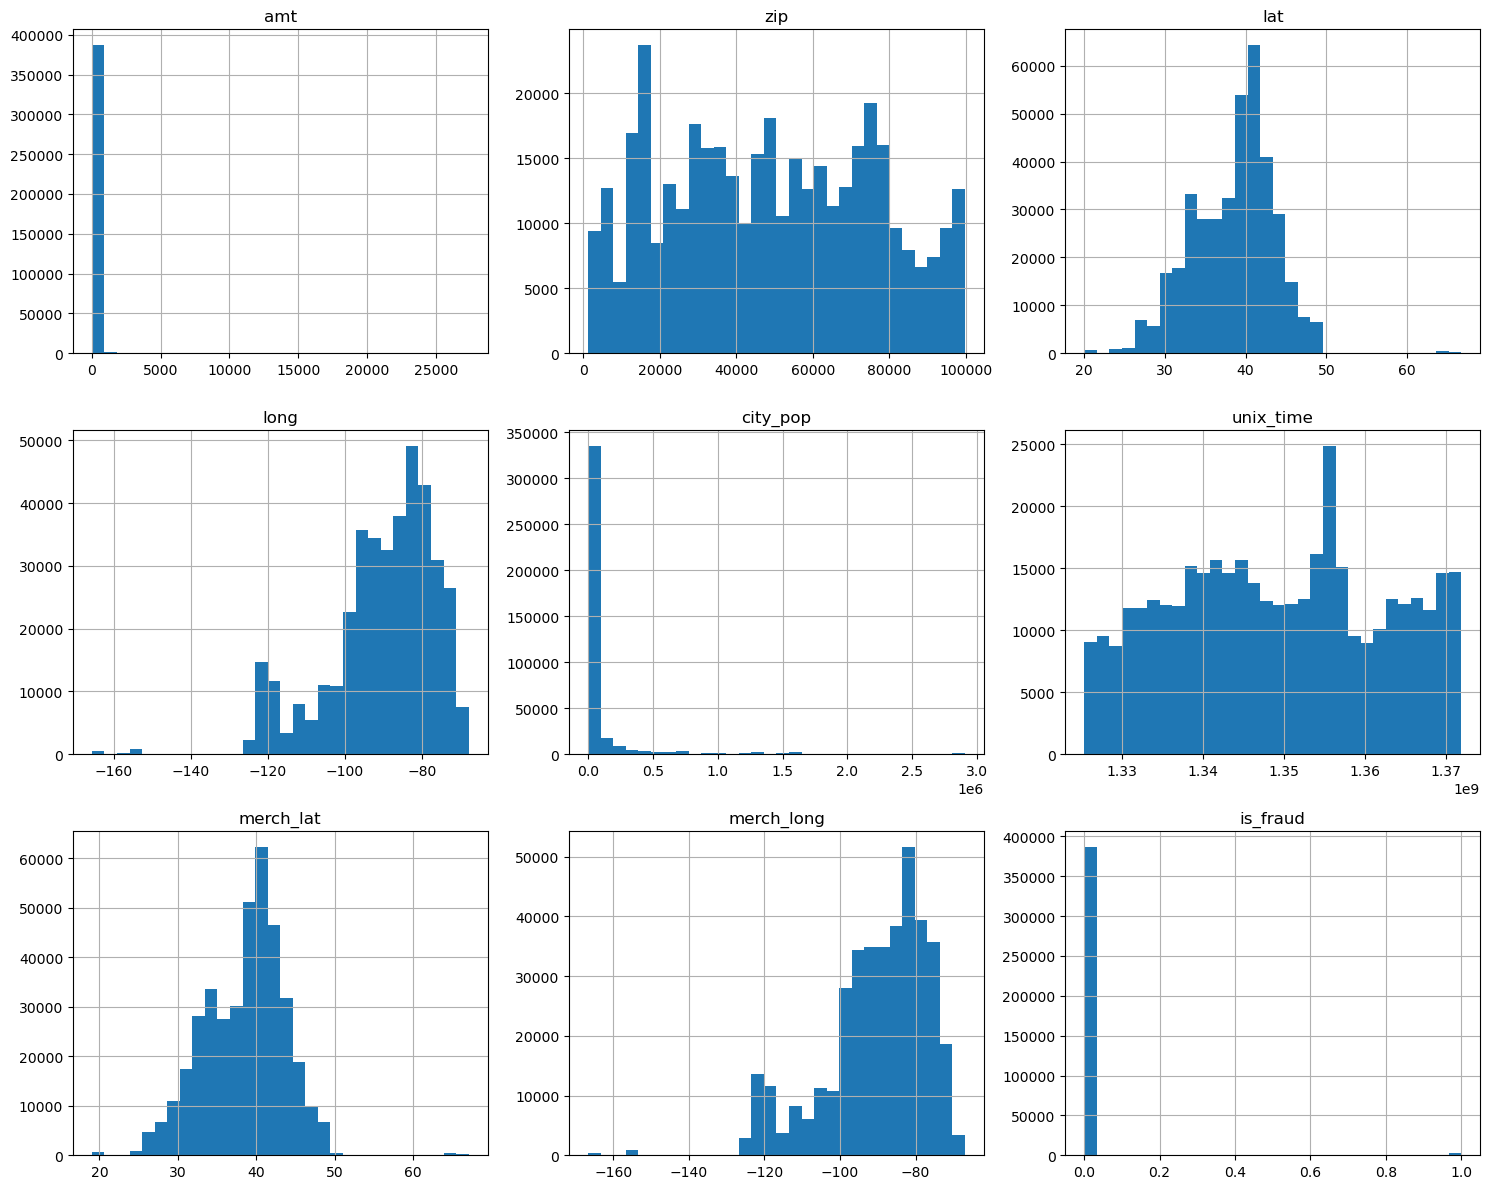

In [8]:
import matplotlib.pyplot as plt

# Plot histograms

df[numerical_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

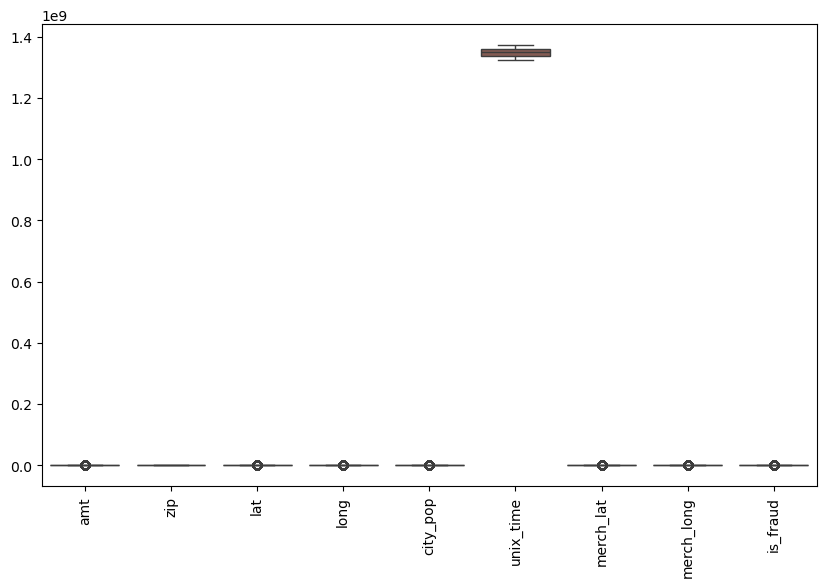

In [11]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.show()

In [12]:
# 4. Are there any missing values in the dataset? If so, how should they be handled?
# Check missing values

missing_values = df.isnull().sum()
missing_values

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [16]:
# For Numerical Columns:

df['amt'] = df['amt'].fillna(df['amt'].median())

In [17]:
# For Categorical Columns:

df['category'] = df['category'].fillna(df['category'].mode()[0])

In [18]:
# 5 • What are the summary statistics (mean, median, min, max, etc.) for numerical variables?
# Select numerical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(['cc_num'])

In [19]:
# Summary statistics

summary_stats = df[num_cols].describe()
summary_stats

,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,389002.000000,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,70.442148,48818.064295,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
std,162.203915,26879.383224,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866
min,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,9.660000,26237.000000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,47.570000,48174.000000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,83.077500,72011.000000,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000


In [20]:
# 6 • Is there any correlation between numerical variables? If so, how strong is the correlation?

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(['cc_num'])   # remove ID column

In [21]:
correlation_matrix = df[num_cols].corr()

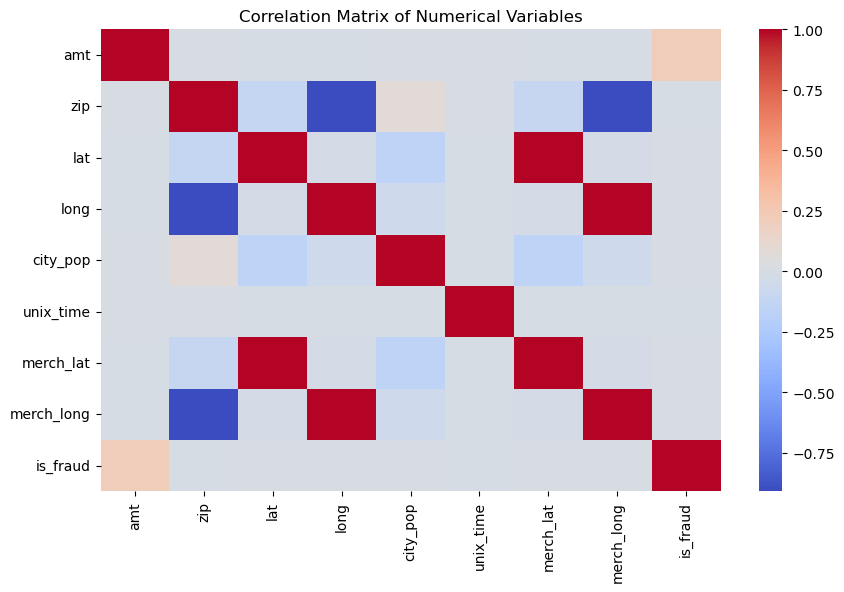

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [23]:
# 7 • How does the distribution of an amt differ across is_fraud categories?

df.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,386750.0,67.834157,156.227752,1.00,9.6200,47.330,82.5000,27390.12
1,2252.0,518.328677,389.127281,1.18,147.8825,365.285,888.3425,1294.83


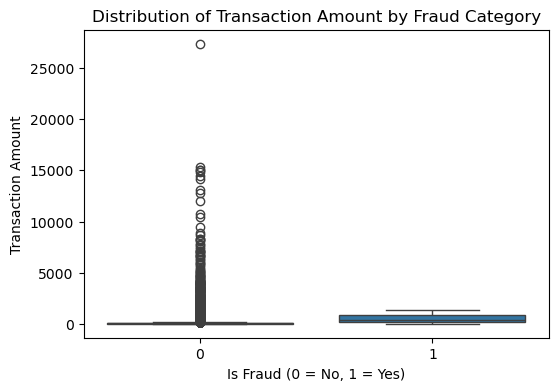

In [25]:
# Visual Comparison Using Boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Distribution of Transaction Amount by Fraud Category")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount")
plt.show()

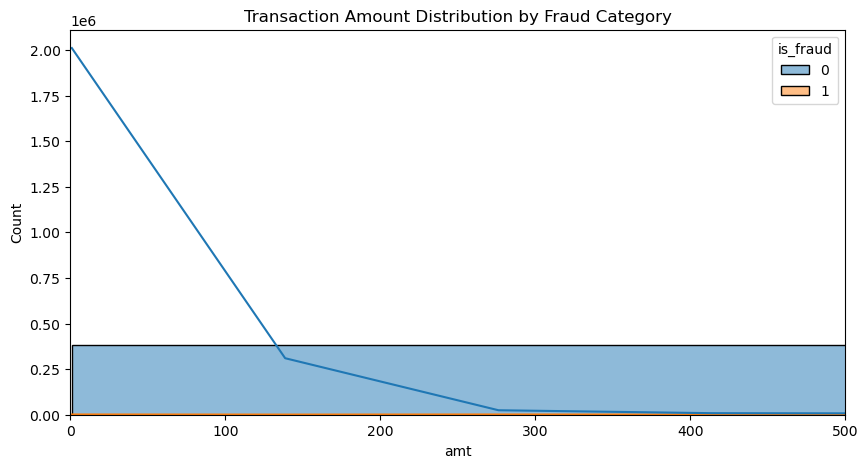

In [26]:
# Optional (Histogram for Better Clarity

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='amt', hue='is_fraud', bins=50, kde=True)
plt.xlim(0,500)   # limit to visualize better
plt.title("Transaction Amount Distribution by Fraud Category")
plt.show()

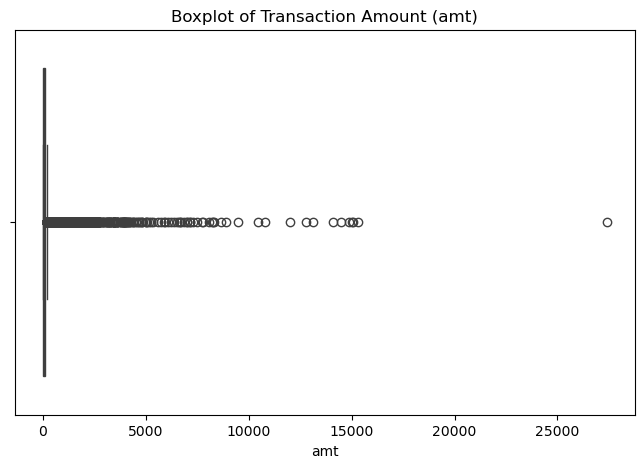

In [27]:
# 8 • Are there any outliers in the city_pop and amt?

# For Transaction Amount (amt)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['amt'])
plt.title("Boxplot of Transaction Amount (amt)")
plt.show()

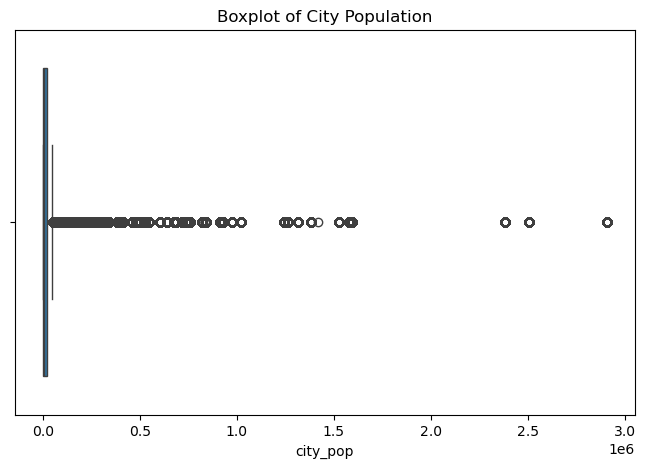

In [28]:
# For City Population (city_pop)

plt.figure(figsize=(8,5))
sns.boxplot(x=df['city_pop'])
plt.title("Boxplot of City Population")
plt.show()

In [29]:
# Confirm Using IQR Method (Statistical Method) # For amt

Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_amt = df[(df['amt'] < lower) | (df['amt'] > upper)]
print("Number of outliers in amt:", outliers_amt.shape[0])

# For city_pop

Q1 = df['city_pop'].quantile(0.25)
Q3 = df['city_pop'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_city = df[(df['city_pop'] < lower) | (df['city_pop'] > upper)]
print("Number of outliers in city_pop:", outliers_city.shape[0])

Number of outliers in amt: 20377
Number of outliers in city_pop: 72813


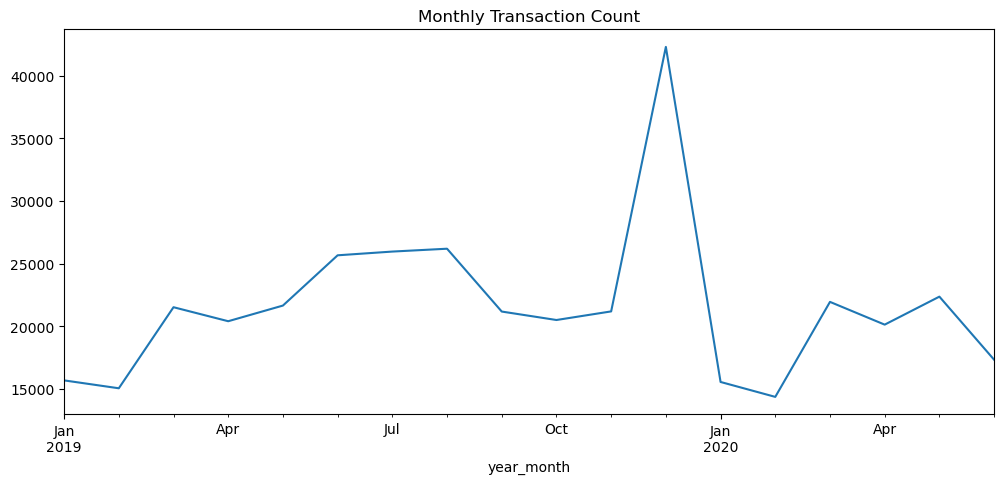

In [30]:
# 9 • Are there any trends or patterns in the data over time (if applicable)?

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], dayfirst=True)

df['year_month'] = df['trans_date_trans_time'].dt.to_period('M')

monthly_transactions = df.groupby('year_month')['trans_num'].count()

monthly_transactions.plot(figsize=(12,5))
plt.title("Monthly Transaction Count")
plt.show()

In [32]:
# 10 • How does the target variable (if available) distribute across different categories?

df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    99.421083
1     0.578917
Name: proportion, dtype: float64

In [33]:
# 11 • Are there any unusual or unexpected values in the dataset that require further investigation?

# Convert DOB to datetime first
df['dob'] = pd.to_datetime(df['dob'], errors='coerce', dayfirst=True)

# Highest and lowest transaction amounts
print("Top 5 Highest Transaction Amounts:")
print(df['amt'].sort_values(ascending=False).head())

print("\nTop 5 Lowest Transaction Amounts:")
print(df['amt'].sort_values().head())


# Extreme City Population Values
print("\nTop 5 Highest City Population Values:")
print(df['city_pop'].sort_values(ascending=False).head())

print("\nTop 5 Lowest City Population Values:")
print(df['city_pop'].sort_values().head())


# Customer Age Calculation and Check
df['age'] = 2020 - df['dob'].dt.year

print("\nAge Summary:")
print(df['age'].describe())

print("\nTop 5 Highest Ages:")
print(df['age'].sort_values(ascending=False).head())

print("\nTop 5 Lowest Ages:")
print(df['age'].sort_values().head())

Top 5 Highest Transaction Amounts:
230422    27390.12
25160     15305.95
72822     15047.03
259179    15034.18
193078    14849.74
Name: amt, dtype: float64

Top 5 Lowest Transaction Amounts:
278269    1.0
267285    1.0
325077    1.0
4906      1.0
378966    1.0
Name: amt, dtype: float64

Top 5 Highest City Population Values:
217583    2906700
384785    2906700
275628    2906700
124595    2906700
251150    2906700
Name: city_pop, dtype: int64

Top 5 Lowest City Population Values:
180534    23
260576    23
196040    23
118841    23
54570     23
Name: city_pop, dtype: int64

Age Summary:
count    389002.000000
mean         46.724811
std          17.378573
min          15.000000
25%          33.000000
50%          45.000000
75%          58.000000
max          96.000000
Name: age, dtype: float64

Top 5 Highest Ages:
192119    96
103955    96
281266    96
6734      96
138958    96
Name: age, dtype: int32

Top 5 Lowest Ages:
322489    15
287122    15
126834    15
203714    15
135262    15
Name

In [34]:
# 12 • Are there any potential data entry errors or inconsistencies in the dataset?

# Check for duplicate transaction IDs
print("Duplicate Transaction Numbers:")
print(df['trans_num'].duplicated().sum())

# Check for negative or zero transaction amounts
print("\nTransactions with amt <= 0:")
print(df[df['amt'] <= 0].shape[0])

# Check invalid gender values
print("\nUnique Gender Values:")
print(df['gender'].unique())

# Check invalid fraud values
print("\nUnique is_fraud Values:")
print(df['is_fraud'].unique())

# Check for invalid latitude/longitude ranges
invalid_lat = df[(df['lat'] < -90) | (df['lat'] > 90)]
invalid_long = df[(df['long'] < -180) | (df['long'] > 180)]

print("\nInvalid Latitude Records:", invalid_lat.shape[0])
print("Invalid Longitude Records:", invalid_long.shape[0])

# Check unrealistic ages
df['dob'] = pd.to_datetime(df['dob'], errors='coerce', dayfirst=True)
df['age'] = 2020 - df['dob'].dt.year

print("\nAge Summary:")
print(df['age'].describe())

print("\nRecords with Age < 18 or Age > 100:")
print(df[(df['age'] < 18) | (df['age'] > 100)].shape[0])

Duplicate Transaction Numbers:
0

Transactions with amt <= 0:
0

Unique Gender Values:
['F' 'M']

Unique is_fraud Values:
[0 1]

Invalid Latitude Records: 0
Invalid Longitude Records: 0

Age Summary:
count    389002.000000
mean         46.724811
std          17.378573
min          15.000000
25%          33.000000
50%          45.000000
75%          58.000000
max          96.000000
Name: age, dtype: float64

Records with Age < 18 or Age > 100:
3951


In [35]:
# 13 • How does the distribution of numerical variables vary between different groups or segments of the dataset?

# Compare numerical distributions across groups

print("Average Transaction Amount by Fraud Status:")
print(df.groupby('is_fraud')['amt'].describe())

print("\nAverage Transaction Amount by Gender:")
print(df.groupby('gender')['amt'].describe())

print("\nCity Population by Fraud Status:")
print(df.groupby('is_fraud')['city_pop'].describe())

Average Transaction Amount by Fraud Status:
             count        mean         std   min       25%      50%       75%  \
is_fraud                                                                        
0         386750.0   67.834157  156.227752  1.00    9.6200   47.330   82.5000   
1           2252.0  518.328677  389.127281  1.18  147.8825  365.285  888.3425   

               max  
is_fraud            
0         27390.12  
1          1294.83  

Average Transaction Amount by Gender:
           count       mean         std  min    25%    50%    75%       max
gender                                                                     
F       213231.0  69.854789  151.442906  1.0   9.10  43.37  83.67  15034.18
M       175771.0  71.154684  174.366858  1.0  11.59  51.82  82.56  27390.12

City Population by Fraud Status:
             count          mean            std   min    25%     50%      75%  \
is_fraud                                                                        
0       

In [36]:
# 14 • What are the top factors that influence the target variable, if applicable?

# Correlation with target variable

corr_with_target = df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

print("Correlation with is_fraud:")
print(corr_with_target)

Correlation with is_fraud:
is_fraud      1.000000
amt           0.210706
age           0.013057
lat           0.002643
merch_lat     0.002406
long          0.001376
merch_long    0.001351
city_pop      0.001176
zip          -0.001220
cc_num       -0.001280
unix_time    -0.006562
Name: is_fraud, dtype: float64


In [37]:
# Fraud rate by category

fraud_category = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)

print("Fraud Rate by Category:")
print(fraud_category)

Fraud Rate by Category:
category
shopping_net      0.016317
misc_net          0.015017
grocery_pos       0.014090
shopping_pos      0.007226
gas_transport     0.004870
travel            0.003445
misc_pos          0.003202
grocery_net       0.002889
personal_care     0.002776
entertainment     0.002418
kids_pets         0.002182
home              0.001762
food_dining       0.001552
health_fitness    0.001516
Name: is_fraud, dtype: float64


In [38]:
df.groupby('gender')['is_fraud'].mean()

gender
F    0.005351
M    0.006321
Name: is_fraud, dtype: float64

# 15• Write an analysis report on performing exploratory data analysis (EDA) using Python in the context of building a fraud detection system for the financial industry.

# Python Analysis Report – Financial Fraud Detection

## Introduction :

Exploratory Data Analysis (EDA) was performed using Python to understand the structure, characteristics, patterns, and potential issues in the credit card transaction dataset. The analysis was performed using Pandas, Matplotlib, and Seaborn to identify important patterns that can support the development of a financial fraud detection system.

## Dataset Overview :

The dataset contains 389,002 transactions and 22 variables after removing the unnecessary index column. The dataset contains transaction details, customer information, merchant information, geographical attributes, transaction amount, time-related variables, and the target variable `is_fraud`.

## Data Quality Analysis :

The dataset was checked for missing values and potential inconsistencies. No missing values were found. Duplicate transaction numbers, invalid transaction amounts, gender and fraud values, geographical ranges, and unrealistic customer ages were also investigated.

## Statistical and Distribution Analysis :

Summary statistics, histograms, boxplots, and skewness analysis were used to understand the numerical variables. The transaction amount was highly right-skewed, indicating the presence of unusually large transactions.

The IQR method identified 20,377 outliers in transaction amount and 72,813 outliers in city population. These values should not automatically be removed because unusual transaction amounts may contain useful information for fraud detection.

## Fraud Analysis :

The target variable `is_fraud` is highly imbalanced. Approximately 99.42% of transactions are non-fraudulent, while only 0.58% are fraudulent.

Fraudulent transactions had a considerably higher average transaction amount than non-fraudulent transactions. The average amount for fraudulent transactions was approximately $518, compared with approximately $68 for non-fraudulent transactions.

## Correlation and Important Factors :

Correlation analysis showed that `amt` had the strongest numerical relationship with the fraud indicator, with a correlation of approximately 0.21. Other numerical variables such as age, latitude, longitude, and city population showed very weak linear relationships with fraud.

Fraud rates also varied across transaction categories. Categories such as shopping_net, misc_net, and grocery_pos showed comparatively higher fraud rates.

## Time and Group Analysis :

Monthly transaction analysis showed variations in transaction activity over time. Numerical variables were also compared across fraud status and gender to identify differences between different groups.

## Conclusion :

The EDA provided important insights into the credit card transaction dataset. The major findings were the highly imbalanced target variable, right-skewed transaction amounts, presence of outliers, and higher average transaction amounts for fraudulent transactions.

Transaction amount and transaction category appear to be useful factors for further investigation. These findings can be used for data preprocessing, feature engineering, and machine-learning model development to build an effective financial fraud detection system.